In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import requests

## Exploring CPF Allocation Rates

In [2]:
# Allocation rate for CPF from data.gov.sg
RESOURCE_ID = "d_97ec9a2ce15cbf253128e48779a3fba0"
BASE_URL = "https://data.gov.sg/api/action/datastore_search"
# https://data.gov.sg/datasets/d_97ec9a2ce15cbf253128e48779a3fba0/view

In [3]:
# Fetch function for data from data.gov.sg
def fetch_full_dataset(resource_id, base_url, page_size=100):
    records = []
    offset = 0
    while True:
        resp = requests.get(base_url, params={
            "resource_id": resource_id,
            "limit": page_size,
            "offset": offset,
        })
        resp.raise_for_status()
        result = resp.json()["result"]
        batch = result["records"]
        if not batch:
            break
        records.extend(batch)
        offset += page_size
        if offset >= result["total"]:
            break
    return pd.DataFrame(records)

In [4]:
# Fetch data and define type of data as imported data automatically treated as string of objects
alloc_df = fetch_full_dataset(RESOURCE_ID, base_url=BASE_URL)
alloc_df['allocation_rate'] = pd.to_numeric(alloc_df['allocation_rate'], errors='coerce')
alloc_df['effective_from'] = pd.to_datetime(alloc_df['effective_from'], format='%Y-%m')
print(alloc_df.head())

print("Number of Unique Account Types:")
print(alloc_df['account_type'].nunique()) # to check number of accounts types within data set
print(alloc_df['account_type'].unique()) # to check the name of the account types within data set
alloc_df.info()

   _id effective_from              age_grp account_type  allocation_rate
0    1     2014-01-01     35 years & below     Ordinary           0.6390
1    2     2014-01-01     35 years & below      Special           0.1666
2    3     2014-01-01     35 years & below     Medisave           0.1944
3    4     2014-01-01  Above 35 - 45 years     Ordinary           0.5834
4    5     2014-01-01  Above 35 - 45 years      Special           0.1944
Number of Unique Account Types:
4
['Ordinary' 'Special' 'Medisave' 'Retirement']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   _id              183 non-null    int64         
 1   effective_from   183 non-null    datetime64[ns]
 2   age_grp          183 non-null    object        
 3   account_type     183 non-null    object        
 4   allocation_rate  183 non-null    float64       
dtypes

In [5]:
# Define plot function using plotly for resuse later
def plot_allocation_trend(df, labels):
    fig, ax = plt.subplots(figsize=(12,6))
    if isinstance(labels, str):
        labels = [labels]
    elif isinstance(labels, list):
        pass
    else:
        raise TypeError("labels must be a string or list")

    for label in labels:
        ax.step(df.index, df[label], where='post', marker='o', label=label)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Date of Revision")
    ax.set_ylabel("Allocation Rate")
    ax.legend()
    plt.tight_layout()
    return plt.show()

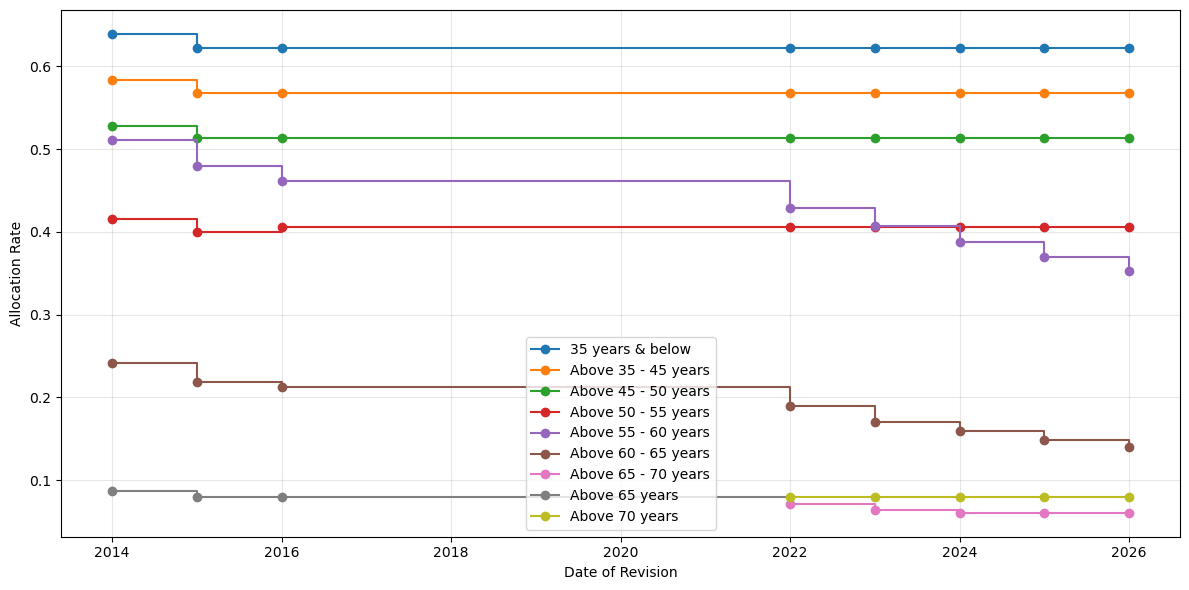

In [6]:
# Checking allocation rates for ordinary account over time
ordinary = alloc_df[alloc_df['account_type'] == 'Ordinary']
ord_pivot = ordinary.pivot_table(
    index='effective_from',
    columns='age_grp',
    values='allocation_rate'
)
plot_allocation_trend(ord_pivot , list(ord_pivot.columns))

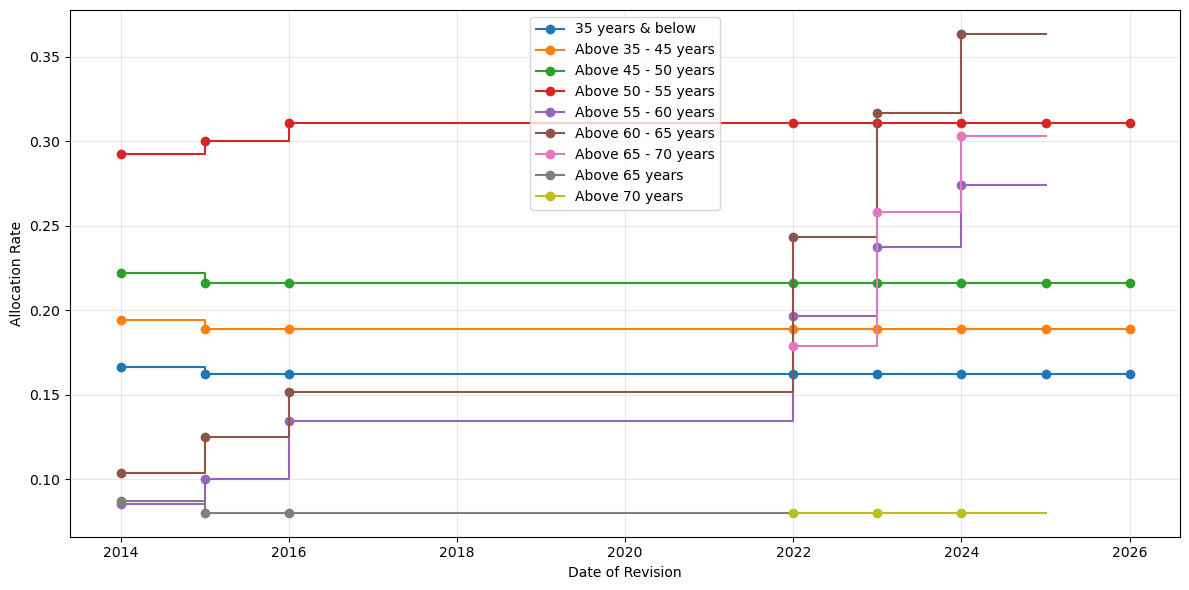

In [7]:
# Checking allocation rates for special account over time
special = alloc_df[alloc_df['account_type'] == 'Special']
special_pivot = special.pivot_table(
    index='effective_from',
    columns='age_grp',
    values='allocation_rate'
)
plot_allocation_trend(special_pivot, list(special_pivot.columns))

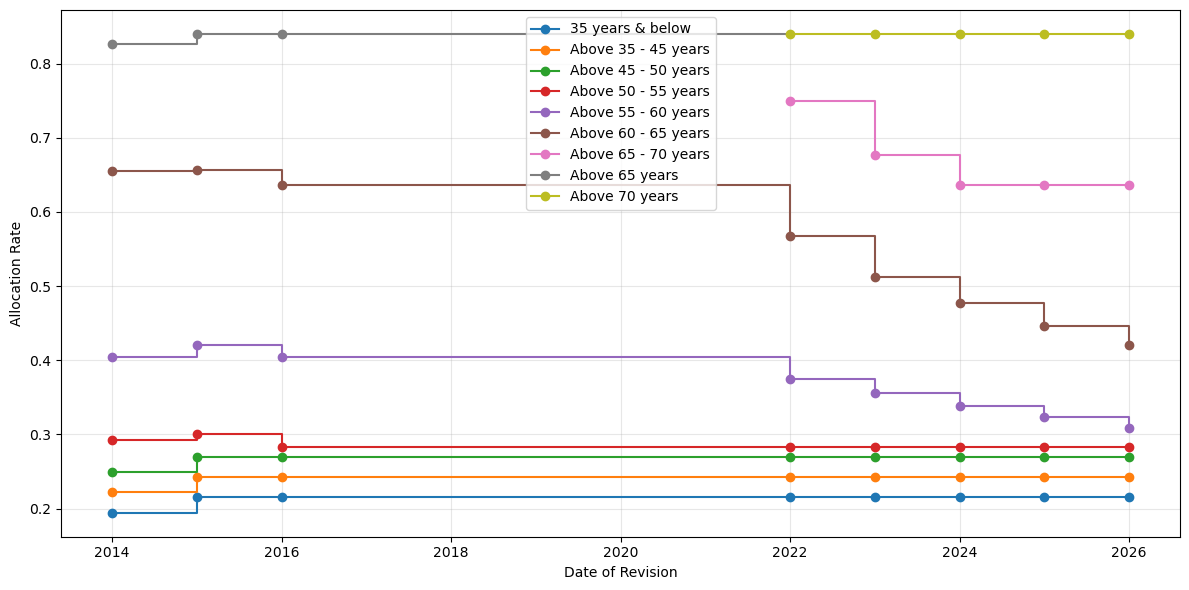

In [8]:
# Checking allocation rates for medisave account over time
medisave = alloc_df[alloc_df['account_type'] == 'Medisave']
medisave_pivot = medisave.pivot_table(
    index='effective_from', 
    columns='age_grp',
    values= 'allocation_rate'
)
plot_allocation_trend(medisave_pivot, list(medisave_pivot.columns))

## Exploring CPF Contribution Rates

In [11]:
# Contribution rate for CPF from data.gov.sg
RESOURCE_ID2 = "d_98ffa142ae0dec40391f78f81d26aca9"
BASE_URL = "https://data.gov.sg/api/action/datastore_search"
# https://data.gov.sg/datasets/d_98ffa142ae0dec40391f78f81d26aca9/view

In [14]:
# Fetch data and ensure that data types are correct
cont_df = fetch_full_dataset(RESOURCE_ID2, base_url=BASE_URL) 
cont_df['contribution_rate'] = pd.to_numeric(cont_df['contribution_rate'], errors='coerce')
cont_df['effective_from'] = pd.to_datetime(cont_df['effective_from'], format='%Y-%m')
cont_df

,_id,effective_from,age_grp,contributing_party,contribution_rate
0,1,1955-07-01,35 years & below,Employer,5.0
1,2,1955-07-01,35 years & below,Employee,5.0
2,3,1955-07-01,Above 35 - 45 years,Employer,5.0
3,4,1955-07-01,Above 35 - 45 years,Employee,5.0
4,5,1955-07-01,Above 45 - 50 years,Employer,5.0
...,...,...,...,...,...
677,678,2026-01-01,Above 60 - 65 years,Employee,12.5
678,679,2026-01-01,Above 65 - 70 years,Employer,9.0
679,680,2026-01-01,Above 65 - 70 years,Employee,7.5
680,681,2026-01-01,Above 70 years,Employer,7.5


In [15]:
cont_df.info()
print(cont_df['contributing_party'].nunique())
print(cont_df['contributing_party'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   _id                 682 non-null    int64         
 1   effective_from      682 non-null    datetime64[ns]
 2   age_grp             682 non-null    object        
 3   contributing_party  682 non-null    object        
 4   contribution_rate   682 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 26.8+ KB
2
['Employer' 'Employee']


In [16]:
# Create pivot table to analyse employer contribution rates
employer_cont = cont_df[cont_df["contributing_party"] == 'Employer']
employer_pivot = employer_cont.pivot_table(
    index='effective_from',
    columns='age_grp',
    values='contribution_rate',
)
employer_pivot.head(10)

age_grp,35 years & below,Above 35 - 45 years,Above 45 - 50 years,Above 50 - 55 years,Above 55 - 60 years,Above 60 - 65 years,Above 65 - 70 years,Above 65 years,Above 70 years
effective_from,,,,,,,,,
1955-07-01,5.0,5.0,5.0,5.0,5.0,5.0,NaN,5.0,NaN
1968-09-01,6.5,6.5,6.5,6.5,6.5,6.5,NaN,6.5,NaN
1970-01-01,8.0,8.0,8.0,8.0,8.0,8.0,NaN,8.0,NaN
1971-01-01,10.0,10.0,10.0,10.0,10.0,10.0,NaN,10.0,NaN
1972-07-01,14.0,14.0,14.0,14.0,14.0,14.0,NaN,14.0,NaN
1973-07-01,15.0,15.0,15.0,15.0,15.0,15.0,NaN,15.0,NaN
1974-07-01,15.0,15.0,15.0,15.0,15.0,15.0,NaN,15.0,NaN
1975-07-01,15.0,15.0,15.0,15.0,15.0,15.0,NaN,15.0,NaN
1977-07-01,15.5,15.5,15.5,15.5,15.5,15.5,NaN,15.5,NaN


In [17]:
# Reused plot trend but for plotting contribution rates
import matplotlib.dates as mdates

def plot_contribution_trend(pivot_df, labels, title):
    fig, ax = plt.subplots(figsize=(15,6))
    ax.set_title(title)
    if isinstance(labels, str):
        labels = [labels]
    elif isinstance(labels, list):
        pass
    else:
        raise TypeError("labels must be a string or list")

    for label in labels:
        ax.step(pivot_df.index, pivot_df[label], where='post', marker='o', label=label)

    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(alpha=0.6)
    ax.set_xlabel("Date of Revision")
    ax.set_ylabel("Contribution Rate (%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches='tight')
    return plt.show()

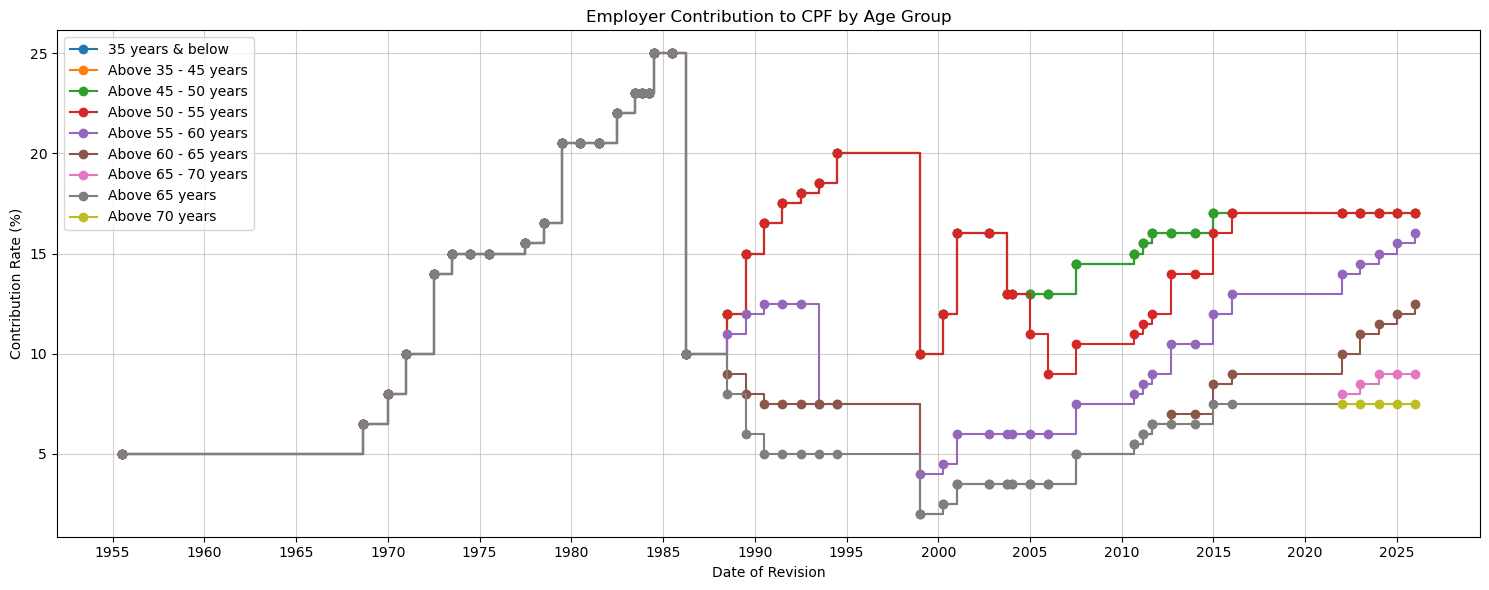

In [18]:
# Plot only employer contribution rates
plot_contribution_trend(employer_pivot, list(employer_pivot.columns), "Employer Contribution to CPF by Age Group")

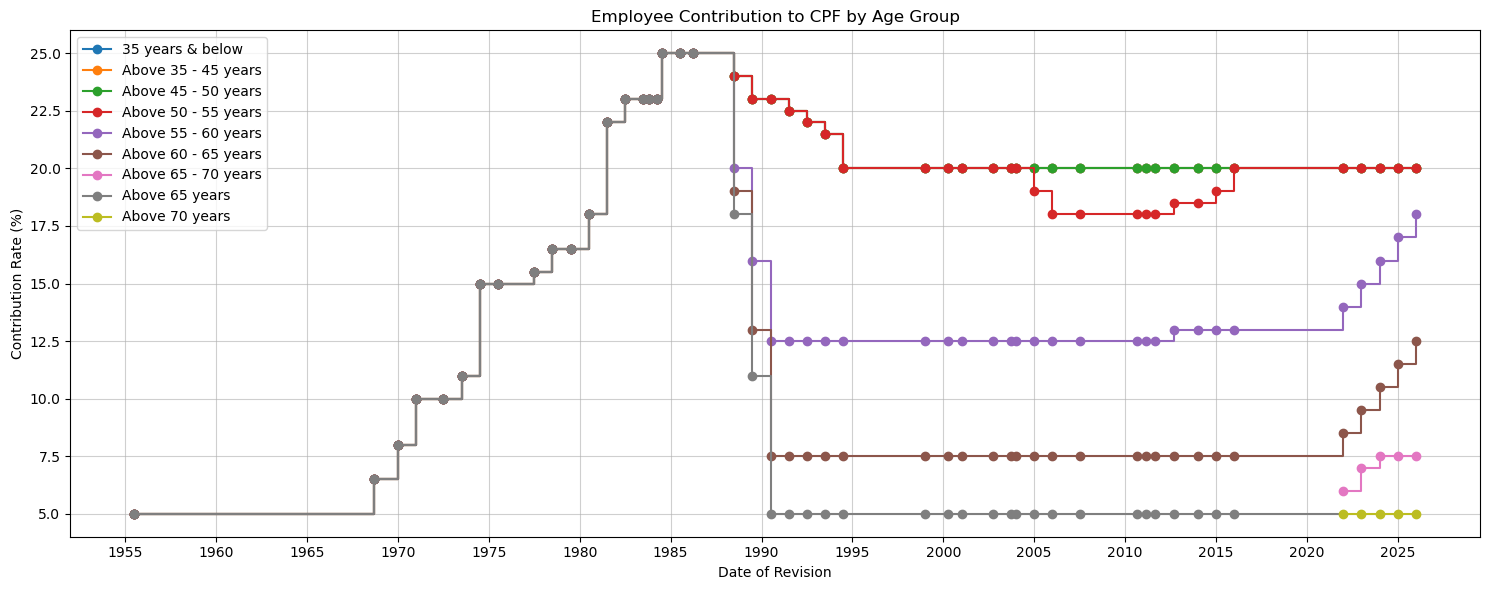

In [19]:
# Plot only employee contribution rates
employee_cont = cont_df[cont_df["contributing_party"] == 'Employee']
employee_pivot = employee_cont.pivot_table(
    index='effective_from',
    columns='age_grp',
    values='contribution_rate',
)
plot_contribution_trend(employee_pivot, list(employee_pivot.columns), "Employee Contribution to CPF by Age Group")

Some of the bands seem to be overlapping one another...so need to check if we can check whichs ones are the same. Just from eyeballng, it looks like the "35 years & below", and the "Above 35-45 years" are overlapped, most likely with the lowest visible band which is the "Above 45-50 years" band.

In [20]:
# Arbitarily setting bands to check where which groups overlap as the plots dont seem to show for '35 years & below', 'Above 35 - 45 years', 'Above 45 - 50'
senior_bands = ['Above 50 - 55 years', 'Above 55 - 60 years', 'Above 60 - 65 years', 'Above 65 - 70 years', 'Above 70 years']
young_bands = ['35 years & below', 'Above 35 - 45 years', 'Above 45 - 50 years']

In [21]:
# Check if the yong bands are currently overlapping in all instances
check = employer_pivot[young_bands].copy()
check['all_identical'] = check.nunique(axis=1) == 1 # use boolean mask
check.head()

age_grp,35 years & below,Above 35 - 45 years,Above 45 - 50 years,all_identical
effective_from,,,,
1955-07-01,5.0,5.0,5.0,True
1968-09-01,6.5,6.5,6.5,True
1970-01-01,8.0,8.0,8.0,True
1971-01-01,10.0,10.0,10.0,True
1972-07-01,14.0,14.0,14.0,True


In [22]:
# As suspected, these groups are seem to move in lockstep even though the data set tracks them seperately. Effectively, the young_bands can be treated as a single "Below 50" band. 
# Given that this is the case, we can now collapse these 3 catergories into one band without data loss. But just to be sure...
check[['all_identical']].value_counts()

all_identical
True             48
Name: count, dtype: int64

In [23]:
# Now to also check for the employee pivot table
check = employee_pivot[young_bands].copy()
check['all_identical'] = check.nunique(axis=1) == 1
check.head()

age_grp,35 years & below,Above 35 - 45 years,Above 45 - 50 years,all_identical
effective_from,,,,
1955-07-01,5.0,5.0,5.0,True
1968-09-01,6.5,6.5,6.5,True
1970-01-01,8.0,8.0,8.0,True
1971-01-01,10.0,10.0,10.0,True
1972-07-01,10.0,10.0,10.0,True


In [24]:
check[['all_identical']].value_counts() # Checks out for employee contribution rates too

all_identical
True             48
Name: count, dtype: int64

In [25]:
# Since the "35 years & below" and "Above 35-45" bands are exactly the same as the "Above 45-50 years" bands, we can just collapse them into one band called "Below 50"
young_bands = ['35 years & below', 'Above 35 - 45 years', 'Above 45 - 50 years']
cont_df_merged = cont_df.copy()
cont_df_merged['age_grp'] = cont_df_merged['age_grp'].apply(
    lambda g: 'Below 50' if g in young_bands else g) # comprehension list to replace age_grp to new "Below 50" band
cont_df_merged = cont_df_merged.groupby(['effective_from', 'age_grp', "contributing_party"], as_index=False)['contribution_rate'].first() #drop duplicates rows and verify
cont_df_merged

,effective_from,age_grp,contributing_party,contribution_rate
0,1955-07-01,Above 50 - 55 years,Employee,5.0
1,1955-07-01,Above 50 - 55 years,Employer,5.0
2,1955-07-01,Above 55 - 60 years,Employee,5.0
3,1955-07-01,Above 55 - 60 years,Employer,5.0
4,1955-07-01,Above 60 - 65 years,Employee,5.0
...,...,...,...,...
485,2026-01-01,Above 65 - 70 years,Employer,9.0
486,2026-01-01,Above 70 years,Employee,5.0
487,2026-01-01,Above 70 years,Employer,7.5
488,2026-01-01,Below 50,Employee,20.0


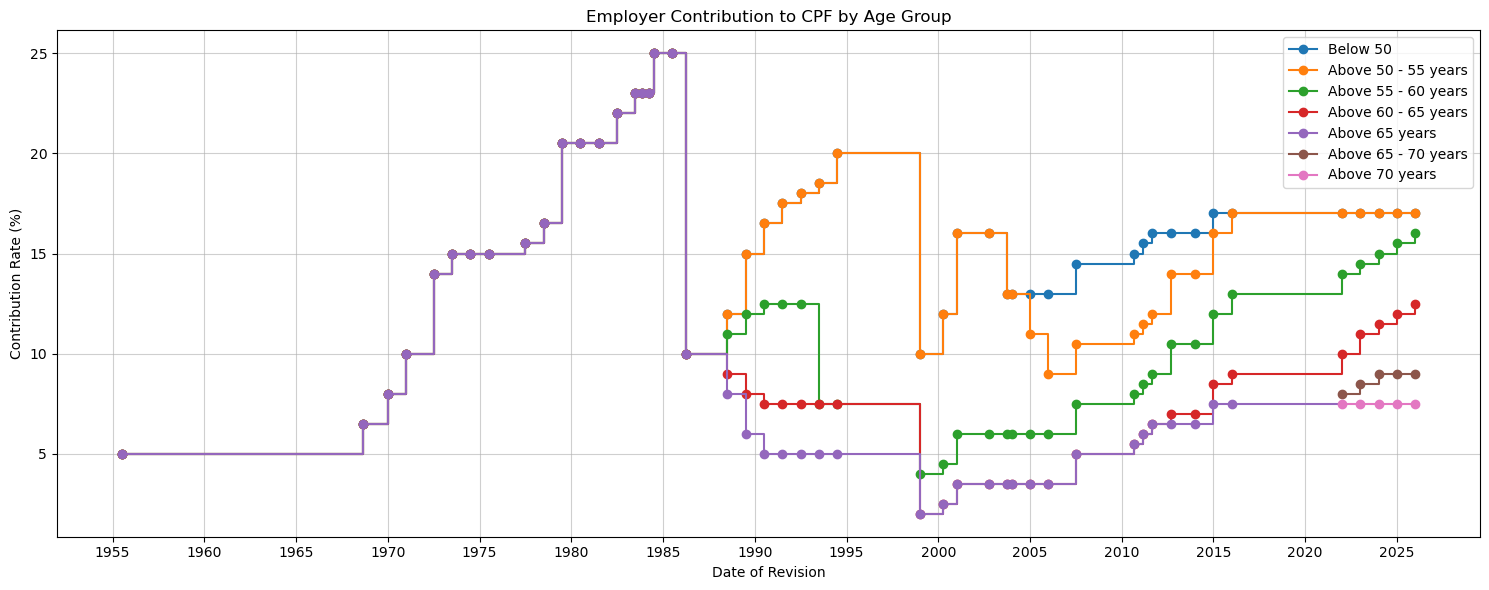

In [26]:
#Rebuild Employer Contribution Graph with new merged age bands 
employer_cont_merged = cont_df_merged[cont_df_merged["contributing_party"] == 'Employer']
employer_pivot = employer_cont_merged.pivot_table(
    index='effective_from',
    columns='age_grp',
    values='contribution_rate',
)
age_order = ['Below 50', 'Above 50 - 55 years', 'Above 55 - 60 years', 'Above 60 - 65 years', 'Above 65 years', 'Above 65 - 70 years', 'Above 70 years']
employer_pivot = employer_pivot[[c for c in age_order if c in employer_pivot.columns]]
plot_contribution_trend(employer_pivot, list(employer_pivot.columns), "Employer Contribution to CPF by Age Group")

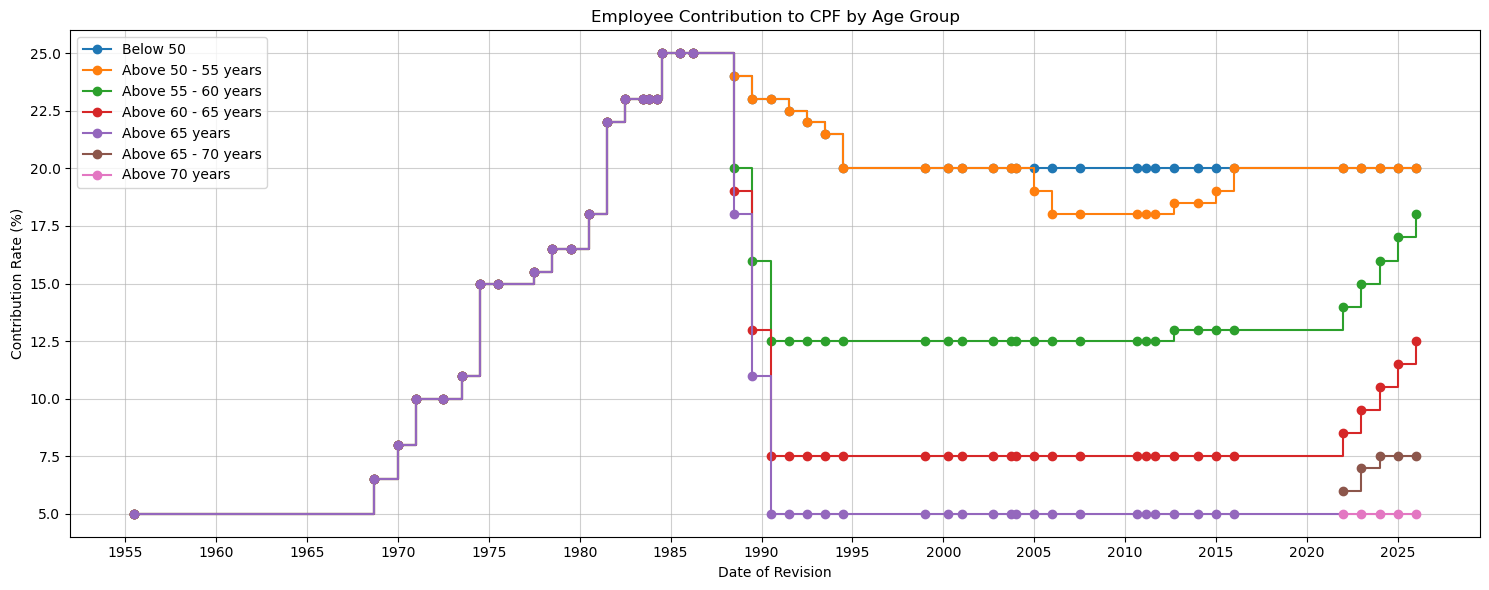

In [27]:
# Rebuild Employee Contribution Graph with merged age bands
employee_cont_merged = cont_df_merged[cont_df_merged["contributing_party"] == 'Employee']
employee_pivot = employee_cont_merged.pivot_table(
    index='effective_from',
    columns='age_grp',
    values='contribution_rate',
)
age_order = ['Below 50', 'Above 50 - 55 years', 'Above 55 - 60 years', 'Above 60 - 65 years', 'Above 65 years', 'Above 65 - 70 years', 'Above 70 years']
employee_pivot = employee_pivot[[c for c in age_order if c in employee_pivot.columns]]
plot_contribution_trend(employee_pivot, list(employee_pivot.columns), "Employee Contribution to CPF by Age Group")

In [28]:
# Create generic pivot table to analyse other stats
pivot_df = cont_df_merged.pivot(
    index=['effective_from', 'age_grp'],
    columns=['contributing_party'],
    values=['contribution_rate'],
).reset_index()
pivot_df

effective_from              age_grp contribution_rate  \
contributing_party                                              Employee   
0                      1955-07-01  Above 50 - 55 years               5.0   
1                      1955-07-01  Above 55 - 60 years               5.0   
2                      1955-07-01  Above 60 - 65 years               5.0   
3                      1955-07-01       Above 65 years               5.0   
4                      1955-07-01             Below 50               5.0   
..                            ...                  ...               ...   
240                    2026-01-01  Above 55 - 60 years              18.0   
241                    2026-01-01  Above 60 - 65 years              12.5   
242                    2026-01-01  Above 65 - 70 years               7.5   
243                    2026-01-01       Above 70 years               5.0   
244                    2026-01-01             Below 50              20.0   

                             
contributing_party Employer  
0                       5.0  
1                       5.0  
2                       5.0  
3                       5.0  
4                       5.0  
..                      ...  
240                    16.0  
241                    12.5  
242                     9.0  
243                     7.5  
244                    17.0  

[245 rows x 4 columns]

In [29]:
# Add two new columns to generic pivot table to analyse (1) Spread of contribution rates and (2) Total Contribution rates
pivot_df['spread'] = pivot_df['contribution_rate', 'Employer'] - pivot_df['contribution_rate','Employee']
pivot_df['total_contribution_rate'] = pivot_df['contribution_rate','Employer'] + pivot_df['contribution_rate',"Employee"]
pivot_df['age_grp'] = pd.Categorical(pivot_df['age_grp'], categories=age_order, ordered=True)
pivot_df

effective_from              age_grp contribution_rate  \
contributing_party                                              Employee   
0                      1955-07-01  Above 50 - 55 years               5.0   
1                      1955-07-01  Above 55 - 60 years               5.0   
2                      1955-07-01  Above 60 - 65 years               5.0   
3                      1955-07-01       Above 65 years               5.0   
4                      1955-07-01             Below 50               5.0   
..                            ...                  ...               ...   
240                    2026-01-01  Above 55 - 60 years              18.0   
241                    2026-01-01  Above 60 - 65 years              12.5   
242                    2026-01-01  Above 65 - 70 years               7.5   
243                    2026-01-01       Above 70 years               5.0   
244                    2026-01-01             Below 50              20.0   

                            spread total_contribution_rate  
contributing_party Employer                                 
0                       5.0    0.0                    10.0  
1                       5.0    0.0                    10.0  
2                       5.0    0.0                    10.0  
3                       5.0    0.0                    10.0  
4                       5.0    0.0                    10.0  
..                      ...    ...                     ...  
240                    16.0   -2.0                    34.0  
241                    12.5    0.0                    25.0  
242                     9.0    1.5                    16.5  
243                     7.5    2.5                    12.5  
244                    17.0   -3.0                    37.0  

[245 rows x 6 columns]

In [30]:
# Defining a more robust plot_trend function to explore Spread and Total Contribution Rates
import seaborn as sns

def plot_trend(pivot_df, column_name, x_axis="Date of Revision", y_axis=None, title=None):
    """
    Plots a step trend given a df, column_name and title
    """
    plt.figure(figsize=(15,6))
    ax = sns.lineplot(
        data=pivot_df,
        x='effective_from',
        y=column_name,
        hue='age_grp',
        drawstyle='steps-post',
        marker='o',
    )
    if y_axis is None:
        raise ValueError("The 'y_axis' parameter cannnot be None. Please provide a label for the Y-axis.")

    if title is None:
        title = f"{y_axis} over Time"

    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.title(title)
    plt.legend(title='Age Group')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, bbox_inches='tight')
    return plt.show()

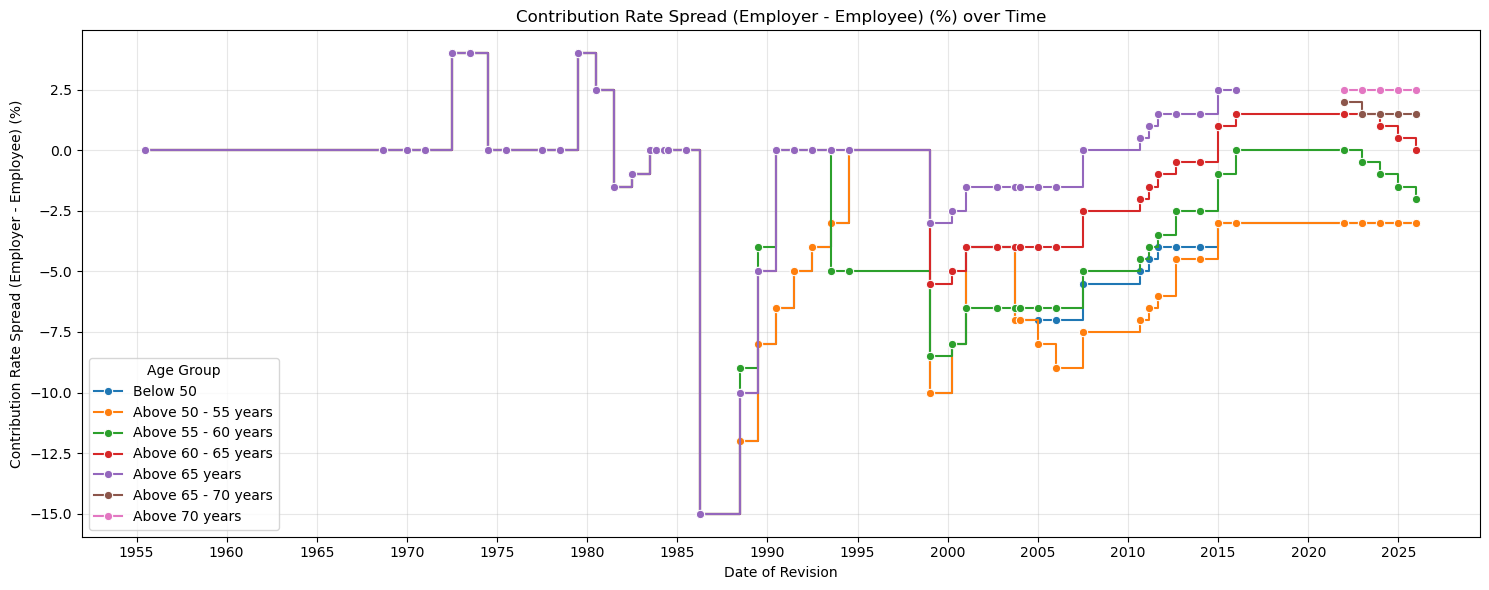

In [31]:
plot_trend(pivot_df, column_name='spread', y_axis="Contribution Rate Spread (Employer - Employee) (%)")

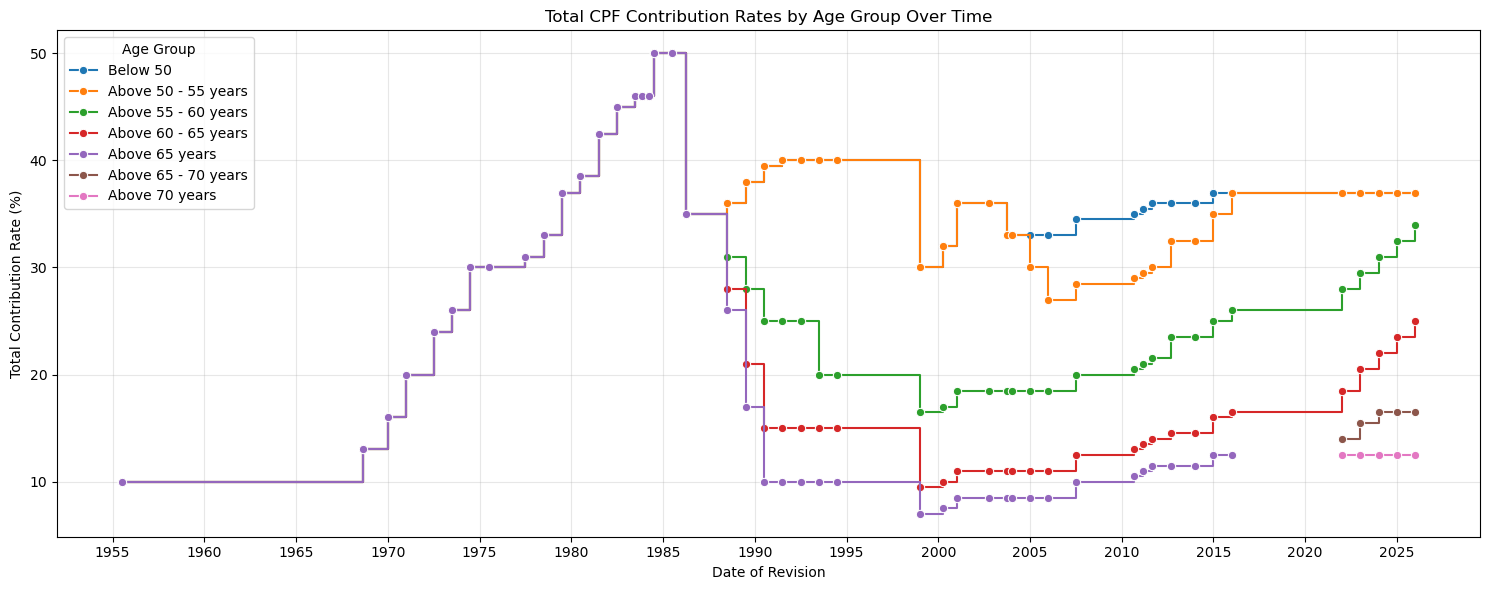

In [32]:
plot_trend(pivot_df, column_name="total_contribution_rate", y_axis="Total Contribution Rate (%)", title="Total CPF Contribution Rates by Age Group Over Time")